# Comparativa global

Vista de pájaro de todos los runs. Incluye:
- **Matriz experimental**: qué combinaciones modelo × motor × config se han medido.
- **Tabla resumen**: un row por run con factores y métricas agregadas.
- **Eficiencia energética**: potencia media vs throughput (frente de Pareto).
- **Alertas**: runs con throttling, generaciones vacías, anomalías.

Este notebook es el que se defiende ante el tribunal.

In [1]:
"""Carga de todos los runs."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Helper para visualización adaptativa ---

def _plot_metric(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
    unit_divisor: float = 1.0,
    unit_label: str = "",
    order: list[str] | None = None,
) -> None:
    """Adaptive visualization based on number of data points per model.

    - n >= 10: histograms with KDE in small multiples (2×2 grid)
    - 3 <= n < 10: stripplot with mean bar, all models together
    - any n: barplot horizontal with error bars and n annotated
    """
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor

    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0

    _order = order or (
        data.groupby("model_label")["_val"]
        .mean().sort_values().index.tolist()
    )
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")

    if min_n >= 10:
        # Histograms with KDE — small multiples
        models = _order
        n_models = len(models)
        ncols = 2
        nrows = (n_models + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(14, 4.5 * nrows), sharey=False)
        axes_flat = list(axes.flatten()) if n_models > 1 else [axes]
        for i, model in enumerate(models):
            ax = axes_flat[i]
            model_data = data[data["model_label"] == model]["_val"]
            n = len(model_data)
            ax.hist(model_data, bins=min(10, n), color=f"C{i}",
                    alpha=0.7, edgecolor="white")
            ax.plot(
                model_data, [0] * n,
                "|", color="black", markersize=14, markeredgewidth=2,
            )
            ax.set_title(f"{model} (n={n})")
            ax.set_xlabel(unit_label or ylabel)
            ax.set_ylabel("Frecuencia")
        for j in range(len(models), len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(full_title, y=1.02)

    elif min_n >= 3:
        # Stripplot with mean bar
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.stripplot(data=data, x="model_label", y="_val",
                      order=_order, jitter=False, size=10,
                      palette="tab10", ax=ax)
        means = data.groupby("model_label")["_val"].mean()
        for i, model in enumerate(_order):
            if model in means.index:
                ax.plot([i - 0.35, i + 0.35],
                        [means[model], means[model]],
                        color="black", lw=2.5, zorder=5)
        # Annotate n
        for i, model in enumerate(_order):
            n = counts.get(model, 0)
            ax.text(i, data[data["model_label"] == model]["_val"].max(),
                    f"n={n}", ha="center", va="bottom", fontsize=9,
                    color="gray")
        ax.set_xlabel("")
        ax.set_ylabel(unit_label or ylabel)
        ax.set_title(full_title)

    else:
        # Barplot horizontal — most honest with n=1
        summary = (
            data.groupby("model_label")["_val"]
            .agg(mean="mean", std="std", n="count")
            .reindex(_order)
            .reset_index()
        )
        fig, ax = plt.subplots(figsize=(10, max(4, len(_order) * 0.8)))
        bars = ax.barh(
            summary["model_label"],
            summary["mean"],
            xerr=summary["std"].fillna(0),
            capsize=4, color="steelblue", alpha=0.8,
        )
        for bar, (_, row) in zip(bars, summary.iterrows()):
            ax.text(
                bar.get_width() * 1.02,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(row['n'])}",
                va="center", fontsize=10, color="gray",
            )
        ax.set_xlabel(unit_label or ylabel)
        ax.set_title(full_title)
        ax.set_ylabel("")

    fig.tight_layout()
    plt.show()

# --- Carga de datos ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "raw_runs"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados: {len(coll)}")

Runs cargados: 12


## Matriz experimental

Qué combinaciones de modelo × motor × fan × acelerador se han medido.
Las casillas vacías o con 0 indican combinaciones pendientes de ejecutar.

In [2]:
matrix = coll.experiment_matrix()
matrix

,model_short,engine,fan,accelerator,n_runs
0,DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M,LLAMA,False,False,1
1,Llama-3.2-1B-Instruct-Q4_K_M,LLAMA,False,False,1
2,Llama-3.2-3B-Instruct-Q4_K_M,LLAMA,False,False,1
3,Ministral-3-3B-Instruct-2512-Q4_K_M,LLAMA,False,False,1
4,deepseek:q4_k_m,OLLAMA,False,False,1
5,gemma-4.5B-3n-E2B-it-Q4_K_M,LLAMA,False,False,1
6,gemma:q4_k_m,OLLAMA,False,False,1
7,granite-4.0-h-micro-Q4_K_M,LLAMA,False,False,1
8,granite:q4_k_m,OLLAMA,False,False,1
9,llama3.2_1b:q4_k_m,OLLAMA,False,False,1


## Tabla resumen

Un row por run con todos los factores experimentales y métricas
agregadas: throughput, latencia, perplejidad, temperatura máxima,
potencia media, energía por token y ratio de throttling.

Esta tabla es la base de las gráficas comparativas que siguen.

In [3]:
summary = coll.summary_df()

display_cols = [
    "model_label", "engine", "test_type",
    "batch_size", "context_size", "temperature",
    "fan", "accelerator",
    "n_prompts", "n_empty_generations",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
    "mbu_pct",
    "model_size_gb",
    "temp_max_c", "temp_mean_c",
    "power_mean_w", "power_max_w",
    "energy_per_token_j",
    "throttled_ratio",
]
cols = [c for c in display_cols if c in summary.columns]
summary[cols].round(3)


,model_label,engine,test_type,batch_size,context_size,temperature,fan,accelerator,n_prompts,n_empty_generations,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean,mbu_pct,model_size_gb,temp_max_c,temp_mean_c,power_mean_w,power_max_w,energy_per_token_j,throttled_ratio
0,ministral,OLLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.100,1.473,424964.275,20014.089,2.103,13.625,1.929,96.35,92.304,5.148,9.007,2.452,0.993
1,ministral,LLAMA,TYPE_1,512,4096,0.0,False,False,15,1,2.858,2.010,407140.417,3629.400,2.810,19.626,2.147,95.80,91.474,4.874,9.678,1.705,0.998
2,llama3.2_3,OLLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.554,1.861,163999.251,12763.883,1.430,16.770,1.807,96.35,93.917,5.033,8.612,1.971,0.990
3,Llama-3.2-,LLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.384,1.740,850692.187,4291.243,2.286,16.534,2.019,96.35,92.954,4.849,9.565,2.034,1.000
4,llama3.2_1,OLLAMA,TYPE_1,512,4096,0.0,False,False,15,0,6.830,5.137,60048.807,4603.280,1.654,16.327,0.695,96.35,92.775,4.925,8.870,0.721,0.987
5,Llama-3.2-,LLAMA,TYPE_1,512,4096,0.0,False,False,15,0,6.861,5.291,350077.805,1306.107,2.360,17.734,0.808,95.80,93.054,4.780,9.096,0.697,0.999
6,granite,OLLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.408,1.882,161774.734,20424.302,1.694,NaN,1.795,96.35,93.887,5.013,8.889,2.082,0.990
7,granite,LLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.781,2.148,143151.125,4423.324,2.854,NaN,1.943,95.80,93.346,4.943,9.606,1.777,0.998
8,gemma,OLLAMA,TYPE_1,512,4096,0.0,False,False,15,0,2.910,2.034,201334.289,12508.432,1.132,23.370,2.508,96.35,93.576,4.952,8.860,1.702,0.986
9,gemma,LLAMA,TYPE_1,512,4096,0.0,False,False,15,0,3.094,2.162,186211.320,5226.373,2.420,32.074,3.309,95.80,93.030,4.856,9.359,1.570,0.998


## MBU — Model Bandwidth Utilization

El MBU mide qué fracción del ancho de banda de memoria del dispositivo se
utiliza realmente durante la inferencia. Un MBU cercano al 100% indica que
la inferencia está limitada por el ancho de banda de memoria (memory-bound),
que es el caso típico de la decodificación secuencial en LLMs sobre CPU.

Fórmula (Chen et al., 2025 — ELIB):
```
MBU = (Model_Size + KV_Cache) / TPOT / Peak_Bandwidth × 100%
```
Peak bandwidth para RPi5 (LPDDR4X-4267, 64-bit): 34.1 GB/s.


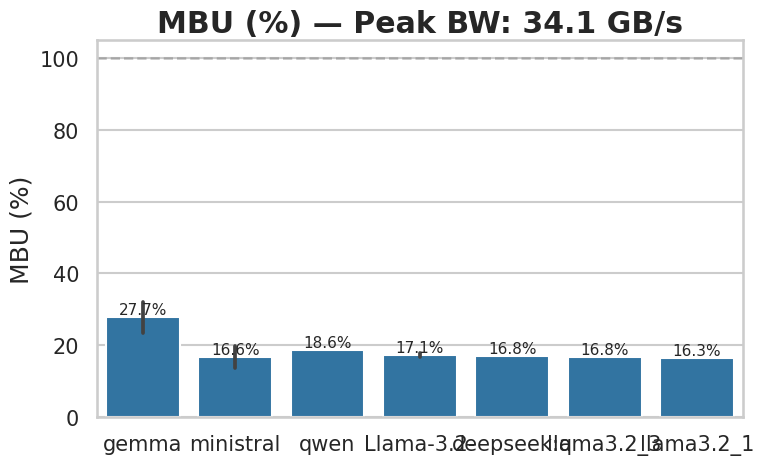

Peak bandwidth objetivo: 34.1 GB/s (RPi5 LPDDR4X-4267).


In [4]:
from monitorviz.viz import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

mbu_data = summary.dropna(subset=["mbu_pct"])

if mbu_data.empty:
    print(
        "Sin datos de MBU — requiere model_info con n_kv_heads y "
        "bits_per_weight. Regenera los runs con el MonitorSystem actualizado."
    )
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    order = mbu_data.sort_values("mbu_pct", ascending=False)["model_label"].tolist()

    sns.barplot(data=mbu_data, x="model_label", y="mbu_pct",
                order=order, ax=ax)
    ax.set_title(f"MBU (%) — Peak BW: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s")
    ax.set_xlabel("")
    ax.set_ylabel("MBU (%)")
    ax.axhline(100, ls="--", color="gray", alpha=0.5)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

    fig.tight_layout()
    plt.show()
    print(f"Peak bandwidth objetivo: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s (RPi5 LPDDR4X-4267).")


## Throughput por modelo

Comparativa directa de tokens/s y palabras/s entre modelos. El boxplot
muestra la variabilidad entre prompts dentro de cada modelo.

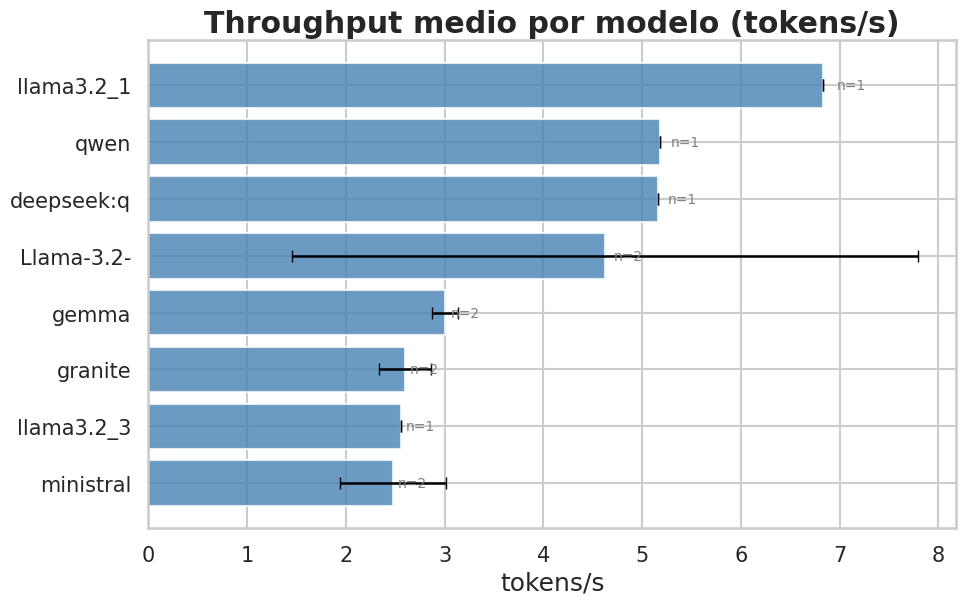

In [5]:
_plot_metric(summary, "tokens_per_s_mean",
             ylabel="tokens/s",
             title="Throughput medio por modelo",
             unit_label="tokens/s")


## Eficiencia energética

Relación entre potencia consumida y throughput. Los modelos más eficientes
están **arriba-izquierda** (alto throughput, baja potencia). Los menos
eficientes están **abajo-derecha**.

La métrica `energy_per_token_j` (julios por token) sintetiza esta relación
en un solo número: menor = mejor.

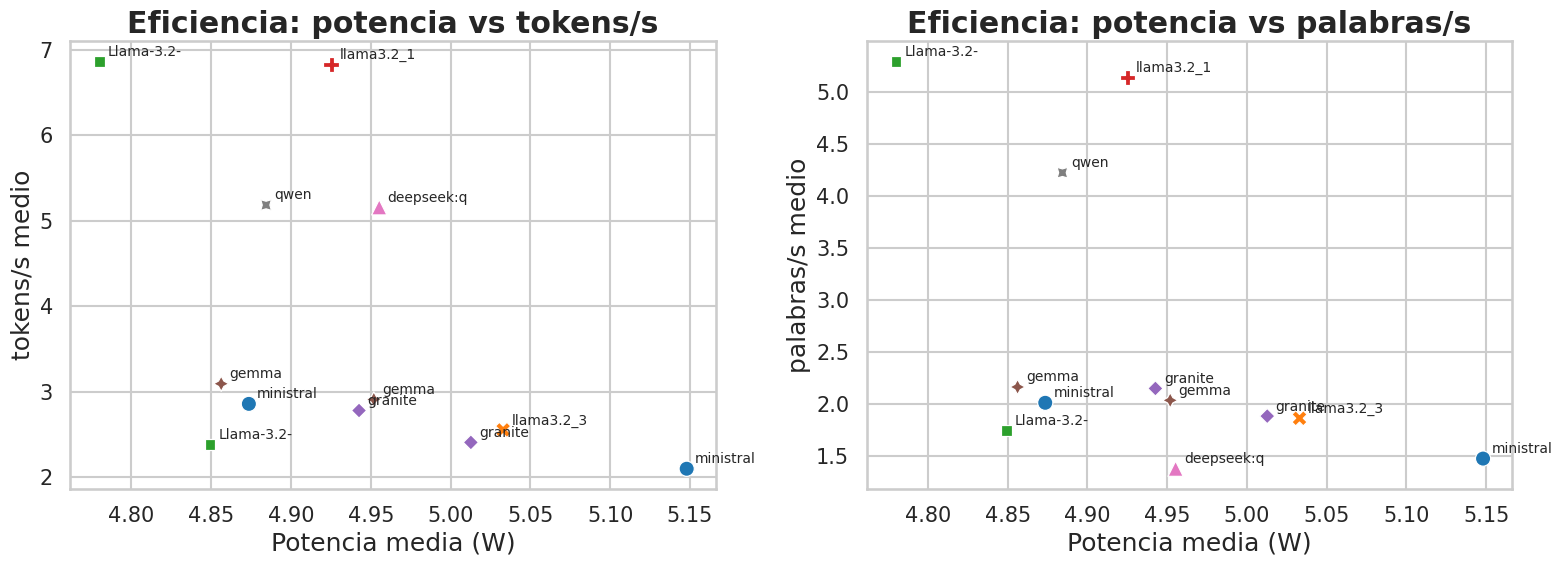

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_col, y_label, title in [
    (axes[0], "tokens_per_s_mean", "tokens/s medio",
     "Eficiencia: potencia vs tokens/s"),
    (axes[1], "words_per_s_mean", "palabras/s medio",
     "Eficiencia: potencia vs palabras/s"),
]:
    sns.scatterplot(
        data=summary, x="power_mean_w", y=y_col,
        hue="model_label", style="model_label",
        s=120, ax=ax, legend=False,
    )
    for _, row in summary.iterrows():
        ax.annotate(
            row["model_label"],
            xy=(row["power_mean_w"], row[y_col]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=10, ha="left",
        )
    ax.set_xlabel("Potencia media (W)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

fig.tight_layout()
plt.show()


## Energía por token

Coste energético de generar un solo token. Es la métrica más honesta
para comparar modelos de tamaños distintos porque normaliza por
rendimiento. Un valor más bajo es mejor.

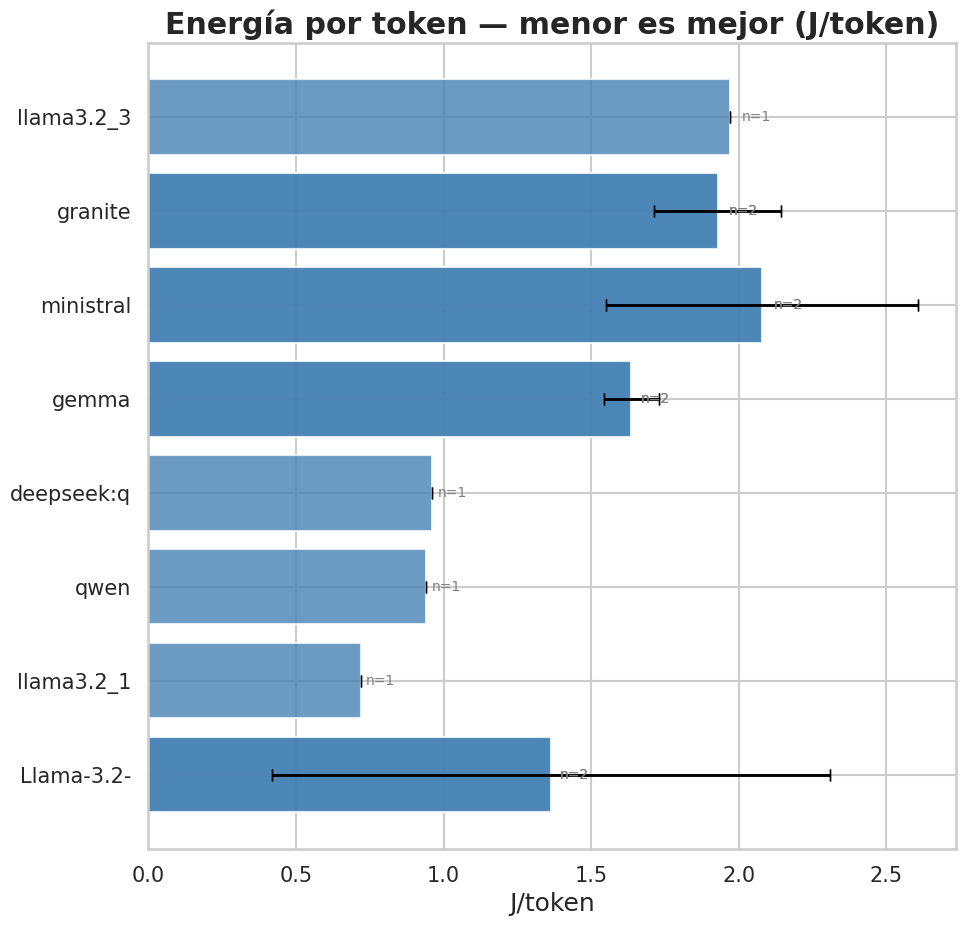

In [7]:
energy = summary.dropna(subset=["energy_per_token_j"])
if not energy.empty:
    _plot_metric(energy, "energy_per_token_j",
                 ylabel="J/token",
                 title="Energía por token — menor es mejor",
                 unit_label="J/token",
                 order=energy.sort_values("energy_per_token_j")
                             ["model_label"].tolist())


## Régimen térmico comparado

Temperatura máxima alcanzada y potencia máxima por modelo. Útil para
evaluar la viabilidad de despliegue sostenido en hardware sin
refrigeración activa.

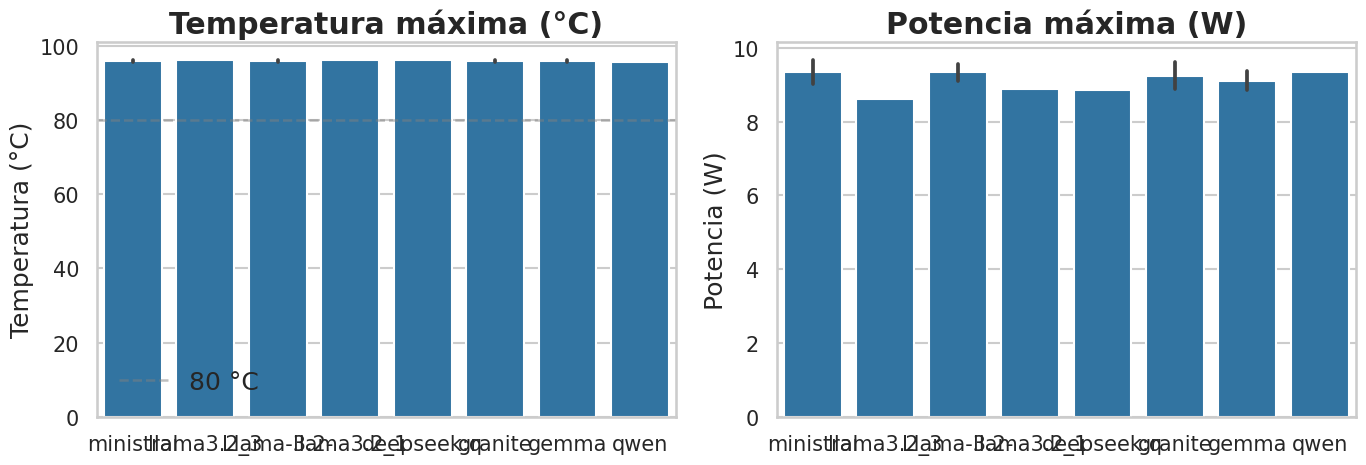

In [8]:
thermal = summary.dropna(subset=["temp_max_c"])
if thermal.empty:
    print("No hay datos de hardware para ningún run.")
else:
    order = thermal.sort_values("temp_max_c", ascending=False)["model_label"].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=thermal, x="model_label", y="temp_max_c",
                order=order, ax=axes[0])
    axes[0].set_title("Temperatura máxima (°C)")
    axes[0].axhline(80, ls="--", color="gray", alpha=0.5, label="80 °C")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Temperatura (°C)")
    axes[0].legend()

    sns.barplot(data=thermal, x="model_label", y="power_max_w",
                order=order, ax=axes[1])
    axes[1].set_title("Potencia máxima (W)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Potencia (W)")

    fig.tight_layout()
    plt.show()

## Trade-offs multidimensionales — Frontera de Pareto

Visualización de trade-offs entre pares de métricas clave. La línea
discontinua roja delimita la **frontera de Pareto**: ningún punto en el
frente puede mejorar una métrica sin empeorar la otra.

- **(izq.)** Potencia media vs throughput: menor potencia y mayor throughput simultáneamente.
- **(der.)** Energía por token vs perplejidad: el mejor modelo minimiza ambas.

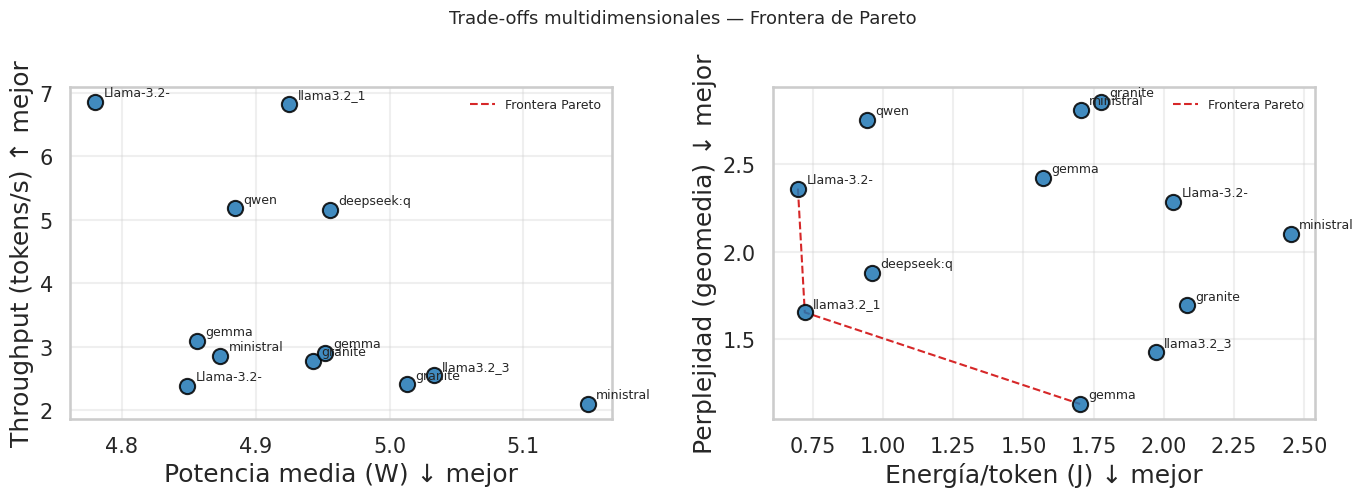

In [9]:
from monitorviz.viz import pareto_panel_multi

pareto_pairs = [
    (
        "power_mean_w", "tokens_per_s_mean",
        "Potencia media (W)", "Throughput (tokens/s)",
        True, False,
    ),
    (
        "energy_per_token_j", "perplexity_geomean",
        "Energía/token (J)", "Perplejidad (geomedia)",
        True, True,
    ),
]

required_cols = {c for pair in pareto_pairs for c in pair[:2]}
pareto_ok = required_cols.issubset(summary.columns) and not summary.dropna(subset=list(required_cols)).empty

if not pareto_ok:
    print("Sin datos suficientes para los gráficos de Pareto.")
else:
    fig = pareto_panel_multi(
        summary,
        pareto_pairs,
        label_col="model_label",
        title="Trade-offs multidimensionales — Frontera de Pareto",
    )
    plt.show()

## Desglose de fases por modelo

Tiempo medio dedicado a cada fase de inferencia: **Load** (cargar el modelo
en RAM), **Prefill** (procesar el prompt) y **Decode** (generar la respuesta
token a token).

El prefill escala con la longitud del prompt; el decode es el cuello de
botella para la experiencia del usuario y determina el TPOT.

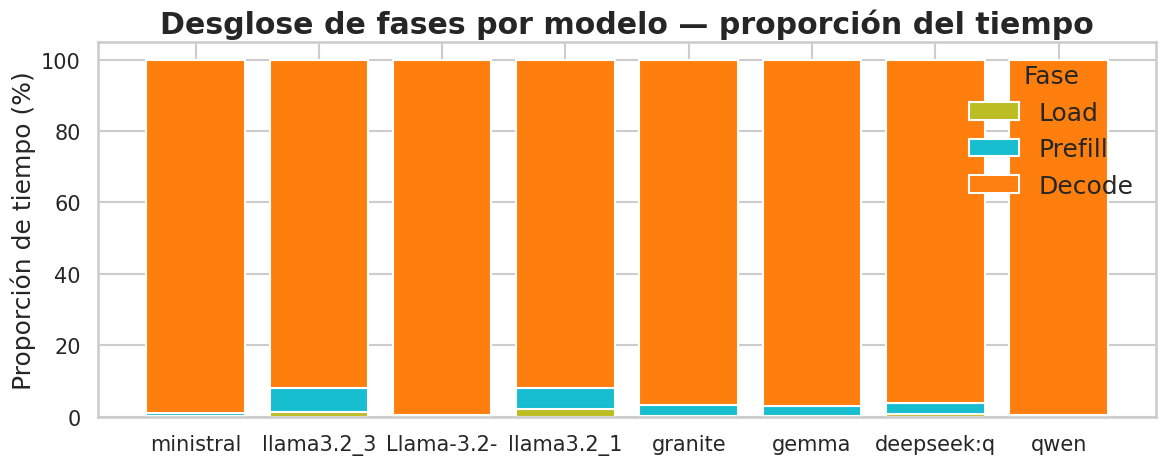

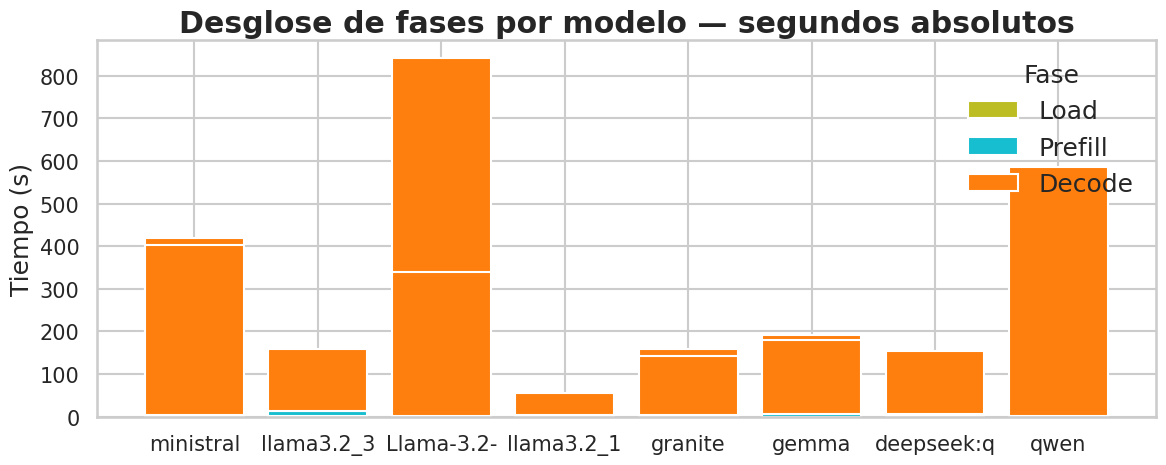

In [10]:
import numpy as np
from monitorviz.viz import phase_breakdown_stacked

# summary_df no agrega duraciones de fase — calculamos desde los runs
phase_rows = []
for r, row in zip(coll.runs, summary.itertuples()):
    non_empty = [p for p in r.prompts if not p.is_empty_generation]
    if not non_empty:
        continue
    phase_rows.append({
        "model_label": row.model_label,
        "load_s_mean": np.mean([p.load_duration_ns / 1e9 for p in non_empty]),
        "prefill_s_mean": np.mean([p.prompt_eval_duration_ns / 1e9 for p in non_empty]),
        "decode_s_mean": np.mean([p.eval_duration_ns / 1e9 for p in non_empty]),
    })
phase_df = pd.DataFrame(phase_rows)

if phase_df.empty:
    print("Sin datos de fases (no hay prompts no vacíos).")
else:
    fig = phase_breakdown_stacked(
        phase_df,
        label_col="model_label",
        title="Desglose de fases por modelo — proporción del tiempo",
        normalized=True,
    )
    plt.show()
    fig2 = phase_breakdown_stacked(
        phase_df,
        label_col="model_label",
        title="Desglose de fases por modelo — segundos absolutos",
        normalized=False,
    )
    plt.show()

## Heatmap de eventos de throttling

Mapa de calor de activaciones de throttling a lo largo del tiempo de cada run.
Cada fila es un run; cada columna, una fracción del tiempo total del run.
El color rojo indica que alguna flag de throttling estaba activa en ese
intervalo. Throttling temprano sugiere una temperatura ambiente elevada
o un disipador insuficiente.

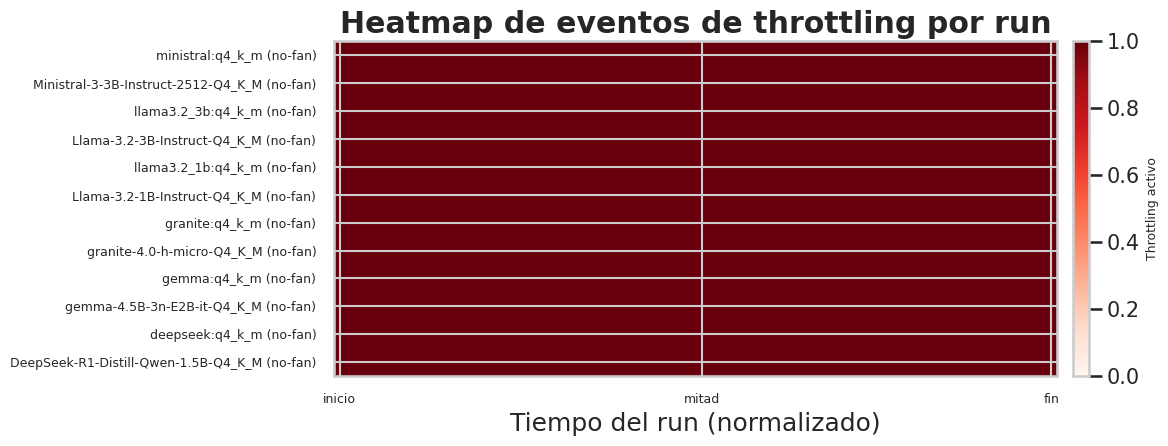

In [11]:
from monitorviz.viz import throttling_heatmap

hw_df_all = coll.hw_metrics_df()
runs_with_hw = [r for r in coll.runs if r.has_hardware_data]

if hw_df_all.empty or not runs_with_hw:
    print("Sin datos de hardware — no se puede generar el heatmap de throttling.")
else:
    fig = throttling_heatmap(
        hw_df_all,
        runs_with_hw,
        bins=60,
        title="Heatmap de eventos de throttling por run",
    )
    plt.show()

## Matriz de correlación entre métricas

Correlación de Pearson entre métricas de rendimiento y hardware.
Las celdas rojas indican correlación positiva fuerte; las azules, negativa.

Con pocos runs (n < 5) los valores son orientativos, no estadísticamente
significativos. Sirven para identificar relaciones a explorar con más datos.

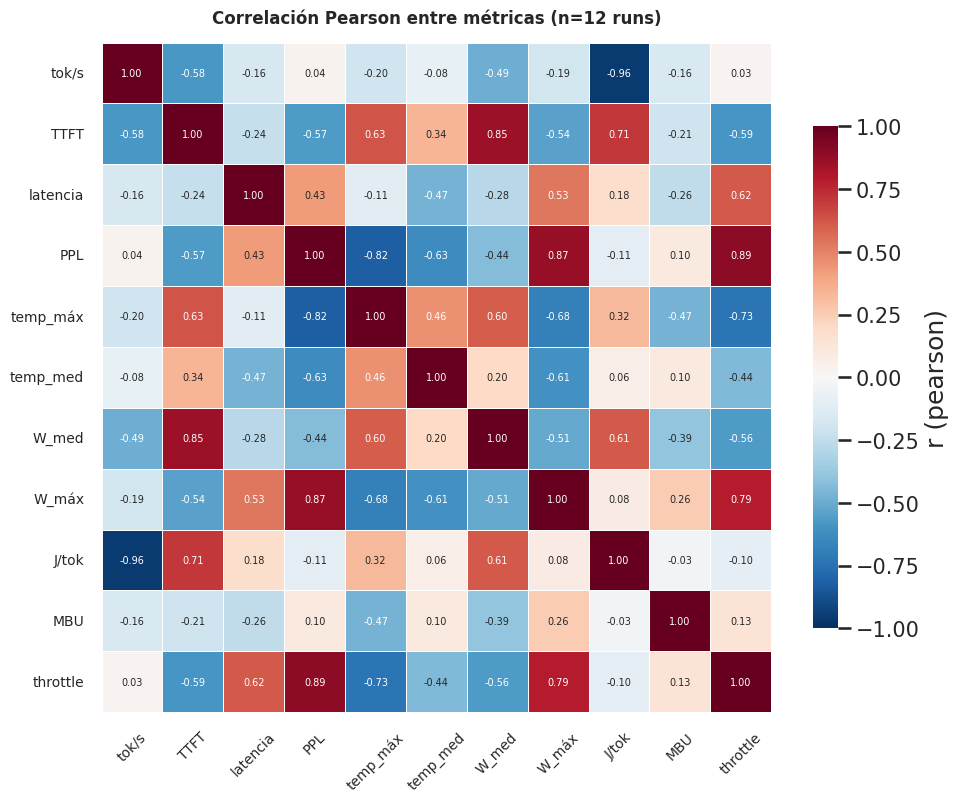

In [12]:
from monitorviz.viz import correlation_heatmap

if len(summary) < 2:
    print(f"Sólo {len(summary)} run(s): se necesitan ≥2 para calcular correlaciones.")
else:
    fig = correlation_heatmap(
        summary,
        title=f"Correlación Pearson entre métricas (n={len(summary)} runs)",
    )
    plt.show()

## Distribución de longitud de respuesta

Histograma de la longitud de respuesta en tokens (`eval_count`) por modelo.
Una varianza alta en la longitud de respuesta puede afectar la estabilidad
de las métricas de throughput agregadas y sesgar la comparativa de latencia.

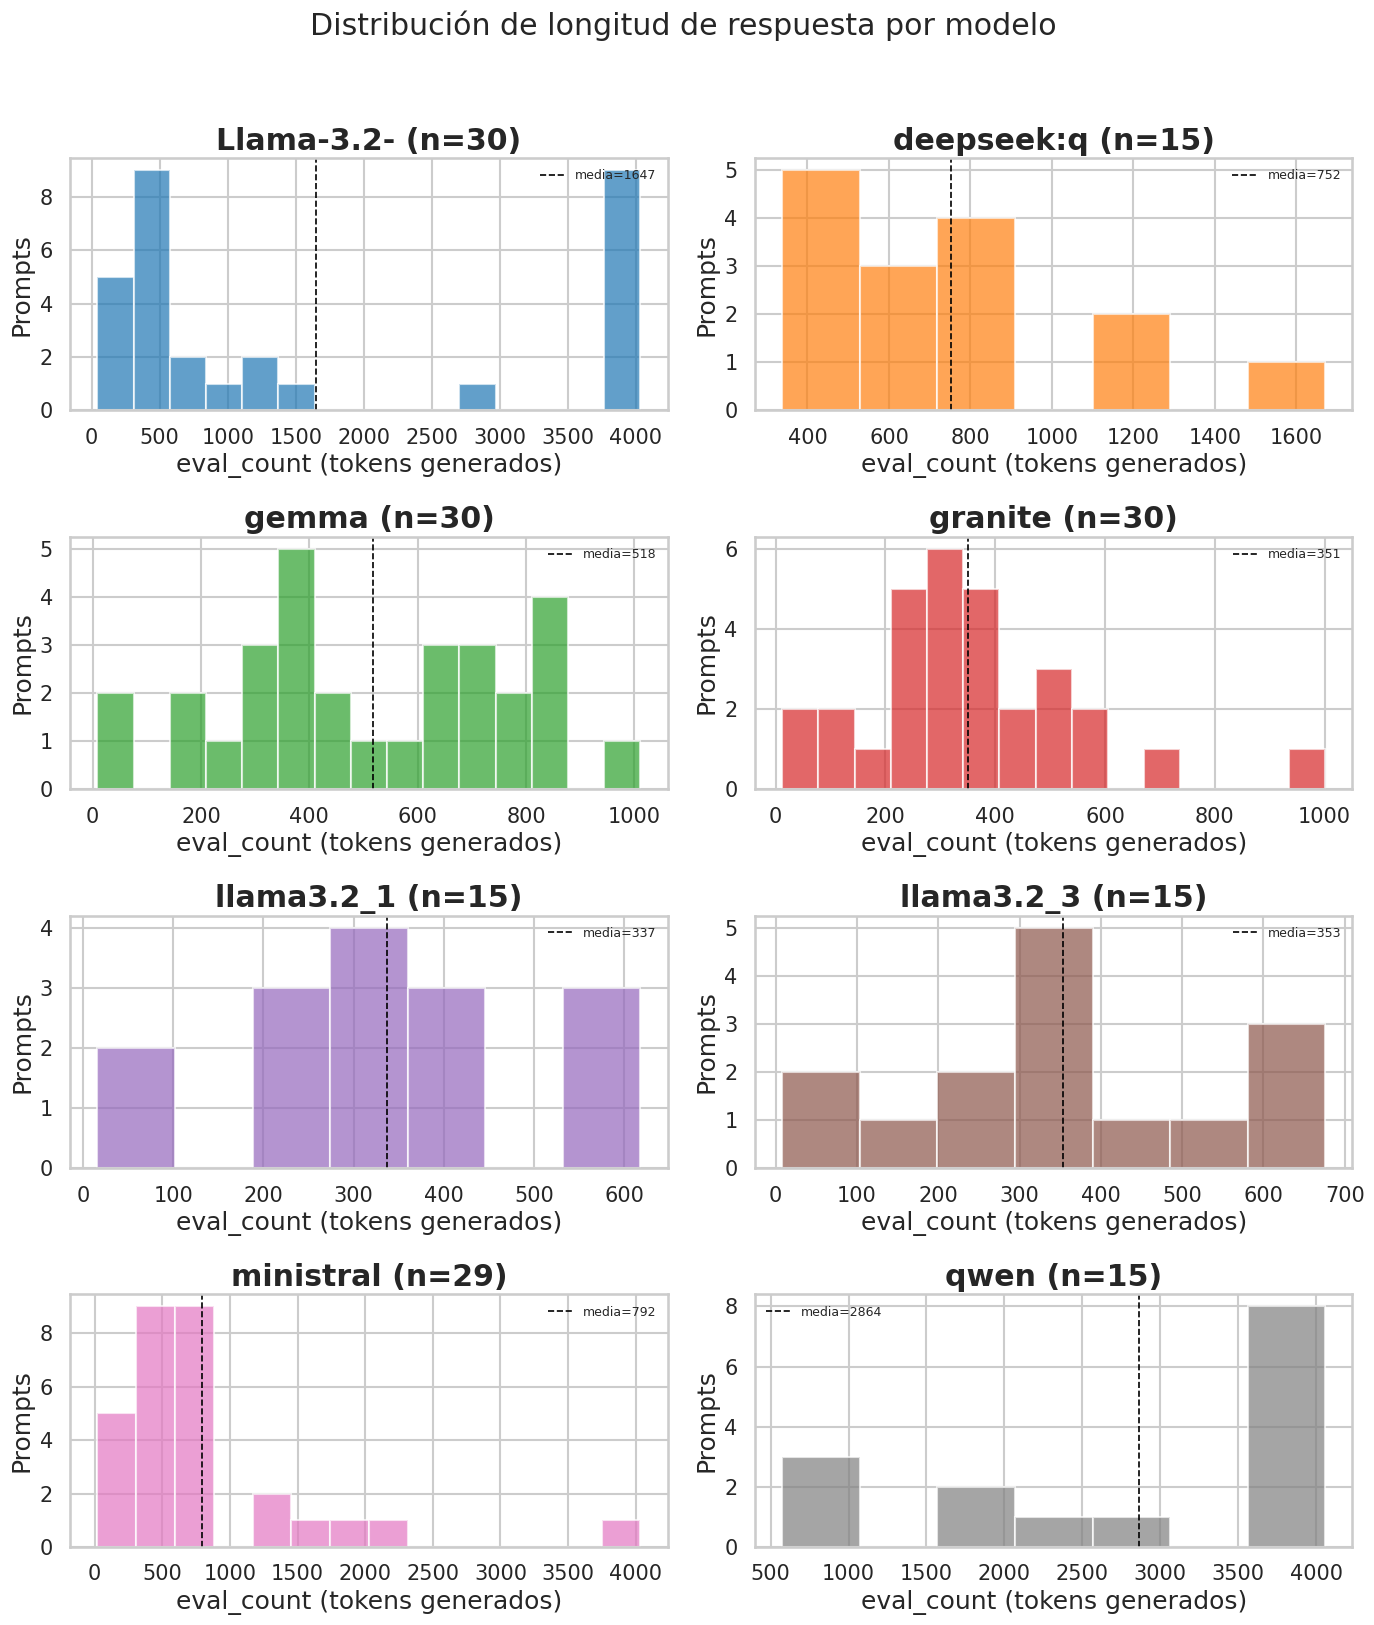

,n_prompts,media,desv_std,min,max
model_label,,,,,
Llama-3.2-,30,1647.2,1652.2,42,4035
deepseek:q,15,751.9,361.8,338,1671
gemma,30,518.3,263.7,9,1011
granite,30,350.6,202.6,12,1001
llama3.2_1,15,337.3,176.2,16,618
llama3.2_3,15,352.9,204.3,8,676
ministral,29,792.2,802.1,21,4035
qwen,15,2863.7,1402.2,574,4059


In [13]:
prompt_df = coll.prompt_metrics_df()

if prompt_df.empty or "eval_count" not in prompt_df.columns:
    print("Sin datos de longitud de respuesta.")
else:
    non_empty_prompts = prompt_df[prompt_df["eval_count"] > 1].copy()
    if non_empty_prompts.empty:
        print("Todos los prompts tienen generación vacía.")
    else:
        models = sorted(non_empty_prompts["model_label"].unique())
        n_models = len(models)
        ncols = min(n_models, 2)
        nrows = (n_models + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(7 * ncols, 4 * nrows),
                                 squeeze=False)
        axes_flat = axes.flatten()
        for i, model in enumerate(models):
            ax = axes_flat[i]
            data = non_empty_prompts[non_empty_prompts["model_label"] == model]["eval_count"]
            n = len(data)
            ax.hist(data, bins=max(5, n // 2), color=f"C{i}",
                    alpha=0.7, edgecolor="white")
            ax.axvline(data.mean(), ls="--", color="black", lw=1.2,
                       label=f"media={data.mean():.0f}")
            ax.set_title(f"{model} (n={n})")
            ax.set_xlabel("eval_count (tokens generados)")
            ax.set_ylabel("Prompts")
            ax.legend(fontsize=9)
        for j in range(len(models), len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle("Distribución de longitud de respuesta por modelo", y=1.02)
        fig.tight_layout()
        plt.show()

        # Tabla resumen
        tbl = (
            non_empty_prompts.groupby("model_label")["eval_count"]
            .agg(["count", "mean", "std", "min", "max"])
            .round(1)
            .rename(columns={
                "count": "n_prompts", "mean": "media",
                "std": "desv_std", "min": "min", "max": "max",
            })
        )
        display(tbl)

## Alertas y anomalías

Detección automática de condiciones problemáticas: throttling activo,
generaciones vacías inesperadas, o configuraciones mixtas que puedan
confundir la comparativa.

In [14]:
alerts = []

throttled = summary[summary["throttled_ratio"] > 0]
if not throttled.empty:
    for _, row in throttled.iterrows():
        alerts.append(
            f"\u26a0\ufe0f  {row['model_label']}: {row['throttled_ratio']*100:.1f}% "
            f"de muestras con throttling activo."
        )

empty_gens = summary[summary["n_empty_generations"] > 0]
if not empty_gens.empty:
    for _, row in empty_gens.iterrows():
        alerts.append(
            f"\u2139\ufe0f  {row['model_label']}: {int(row['n_empty_generations'])}/"
            f"{int(row['n_prompts'])} prompts con generaci\u00f3n vac\u00eda."
        )

configs = summary[["batch_size", "context_size", "temperature"]].drop_duplicates()
if len(configs) > 1:
    alerts.append(
        "\u26a0\ufe0f  Hay runs con configuraciones distintas (batch_size, context_size "
        "o temperature). Las comparativas directas entre estos runs est\u00e1n "
        "confundidas por m\u00faltiples variables."
    )

if alerts:
    for a in alerts:
        print(a)
else:
    print("\u2705 Sin alertas.")


⚠️  ministral: 99.3% de muestras con throttling activo.
⚠️  ministral: 99.8% de muestras con throttling activo.
⚠️  llama3.2_3: 99.0% de muestras con throttling activo.
⚠️  Llama-3.2-: 100.0% de muestras con throttling activo.
⚠️  llama3.2_1: 98.7% de muestras con throttling activo.
⚠️  Llama-3.2-: 99.9% de muestras con throttling activo.
⚠️  granite: 99.0% de muestras con throttling activo.
⚠️  granite: 99.8% de muestras con throttling activo.
⚠️  gemma: 98.6% de muestras con throttling activo.
⚠️  gemma: 99.8% de muestras con throttling activo.
⚠️  deepseek:q: 99.4% de muestras con throttling activo.
⚠️  qwen: 100.0% de muestras con throttling activo.
ℹ️  ministral: 1/15 prompts con generación vacía.


> **Nota metodológica**: el ratio de throttling expresa el porcentaje de
> muestras de hardware con alguna flag activa (`under_voltage`, `freq_capped`,
> `throttled` o `soft_throttled`) durante **este run concreto**. No es una
> propiedad intrínseca del modelo. A igual duración y condiciones térmicas
> iniciales, la comparativa entre modelos es válida. Runs más largos o con
> temperatura ambiente más alta tenderán a un ratio mayor.


## Resumen para la memoria

Texto generado automáticamente con los hallazgos principales,
listo para integrar en la sección de resultados del TFG.

In [15]:
s = summary.sort_values("tokens_per_s_mean", ascending=False)

lines = [
    f"Se han evaluado {len(s)} configuraciones modelo/motor sobre Raspberry Pi 5.",
    "",
    "**Throughput (tokens/s, de mayor a menor):**",
]
for _, row in s.iterrows():
    tps = row.get("tokens_per_s_mean", float("nan"))
    wps = row.get("words_per_s_mean", float("nan"))
    lines.append(
        f"  - {row['model_label']} ({row['engine']}): "
        f"{tps:.2f} tokens/s, {wps:.2f} palabras/s"
    )

lines.append("")
energy_col = "energy_per_token_j"
if energy_col in s.columns and s[energy_col].notna().any():
    best = s.loc[s[energy_col].idxmin()]
    worst = s.loc[s[energy_col].idxmax()]
    lines.append(
        f"**Eficiencia energ\u00e9tica**: el m\u00e1s eficiente es "
        f"{best['model_label']} ({best[energy_col]:.4f} J/token), "
        f"el menos eficiente es {worst['model_label']} "
        f"({worst[energy_col]:.4f} J/token)."
    )

lines.append("")
throttled = summary[summary["throttled_ratio"] > 0]
if throttled.empty:
    lines.append("**Throttling**: ning\u00fan run present\u00f3 throttling.")
else:
    names = ", ".join(throttled["model_label"].tolist())
    lines.append(f"**Throttling**: detectado en {names}.")

for line in lines:
    print(line)


Se han evaluado 12 configuraciones modelo/motor sobre Raspberry Pi 5.

**Throughput (tokens/s, de mayor a menor):**
  - Llama-3.2- (LLAMA): 6.86 tokens/s, 5.29 palabras/s
  - llama3.2_1 (OLLAMA): 6.83 tokens/s, 5.14 palabras/s
  - qwen (LLAMA): 5.18 tokens/s, 4.22 palabras/s
  - deepseek:q (OLLAMA): 5.16 tokens/s, 1.38 palabras/s
  - gemma (LLAMA): 3.09 tokens/s, 2.16 palabras/s
  - gemma (OLLAMA): 2.91 tokens/s, 2.03 palabras/s
  - ministral (LLAMA): 2.86 tokens/s, 2.01 palabras/s
  - granite (LLAMA): 2.78 tokens/s, 2.15 palabras/s
  - llama3.2_3 (OLLAMA): 2.55 tokens/s, 1.86 palabras/s
  - granite (OLLAMA): 2.41 tokens/s, 1.88 palabras/s
  - Llama-3.2- (LLAMA): 2.38 tokens/s, 1.74 palabras/s
  - ministral (OLLAMA): 2.10 tokens/s, 1.47 palabras/s

**Eficiencia energética**: el más eficiente es Llama-3.2- (0.6967 J/token), el menos eficiente es ministral (2.4519 J/token).

**Throttling**: detectado en ministral, ministral, llama3.2_3, Llama-3.2-, llama3.2_1, Llama-3.2-, granite, granit

## Rendimiento vs arquitectura del modelo

Relación entre métricas de rendimiento y parámetros de arquitectura.
Disponible solo para los modelos que tienen `model_info` exportado por
el MonitorSystem.

- **TTFT vs embedding_length**: el prefill procesa el prompt con la
  dimensión del embedding; mayor embedding → más cómputo por token.
- **tokens/s vs n_params**: la velocidad de decode escala inversamente
  con el número de parámetros a igual hardware.
- **TTLM vs n_params**: cargar el modelo desde disco depende de su
  tamaño total en bytes.


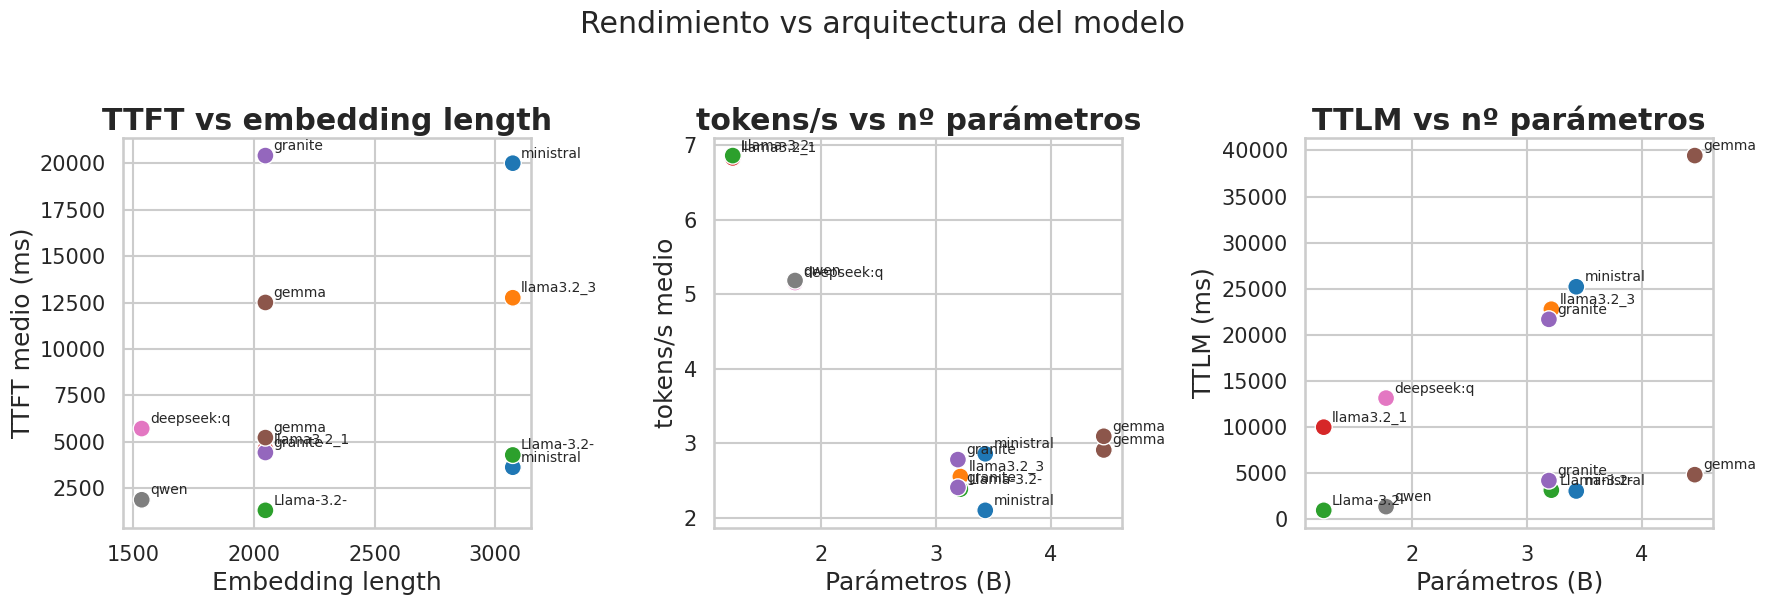

In [16]:
arch_data = summary.dropna(subset=["n_params_from_info", "embedding_length_from_info"], how="all") if "n_params_from_info" in summary.columns else summary.iloc[:0]

# Extraer campos de model_info al summary_df si no están ya como columnas
if "n_params_from_info" not in summary.columns:
    summary["n_params_from_info"] = [
        r.summary.model_info.get("n_params") if r.summary.model_info else None
        for r in coll.runs
    ]
    summary["embedding_length_from_info"] = [
        r.summary.model_info.get("embedding_length") if r.summary.model_info else None
        for r in coll.runs
    ]
    # TTLM: load_duration_ns del primer prompt no vacío
    ttlm_list = []
    for r in coll.runs:
        non_empty = [p for p in r.prompts if not p.is_empty_generation]
        ttlm = non_empty[0].load_duration_ns / 1e6 if non_empty else None
        ttlm_list.append(ttlm)
    summary["ttlm_ms"] = ttlm_list

arch_data = summary.dropna(
    subset=["n_params_from_info", "embedding_length_from_info"]
).copy()
arch_data["n_params_b"] = arch_data["n_params_from_info"] / 1e9

if arch_data.empty:
    print(
        "Sin datos de arquitectura. Requiere runs con model_info "
        "(MonitorSystem actualizado)."
    )
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1) TTFT vs embedding_length
    ax = axes[0]
    sns.scatterplot(data=arch_data, x="embedding_length_from_info",
                    y="ttft_ms_mean", hue="model_label",
                    s=150, ax=ax, legend=False)
    for _, row in arch_data.iterrows():
        ax.annotate(row["model_label"],
                    (row["embedding_length_from_info"], row["ttft_ms_mean"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("TTFT vs embedding length")
    ax.set_xlabel("Embedding length")
    ax.set_ylabel("TTFT medio (ms)")

    # 2) tokens/s vs n_params (en billones)
    ax = axes[1]
    sns.scatterplot(data=arch_data, x="n_params_b",
                    y="tokens_per_s_mean", hue="model_label",
                    s=150, ax=ax, legend=False)
    for _, row in arch_data.iterrows():
        ax.annotate(row["model_label"],
                    (row["n_params_b"], row["tokens_per_s_mean"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("tokens/s vs nº parámetros")
    ax.set_xlabel("Parámetros (B)")
    ax.set_ylabel("tokens/s medio")

    # 3) TTLM vs n_params
    ax = axes[2]
    ttlm_data = arch_data.dropna(subset=["ttlm_ms"])
    if not ttlm_data.empty:
        sns.scatterplot(data=ttlm_data, x="n_params_b",
                        y="ttlm_ms", hue="model_label",
                        s=150, ax=ax, legend=False)
        for _, row in ttlm_data.iterrows():
            ax.annotate(row["model_label"],
                        (row["n_params_b"], row["ttlm_ms"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("TTLM vs nº parámetros")
    ax.set_xlabel("Parámetros (B)")
    ax.set_ylabel("TTLM (ms)")

    fig.suptitle("Rendimiento vs arquitectura del modelo", y=1.02)
    fig.tight_layout()
    plt.show()


## Resumen global: gráficas de radar

Visualización polar de las métricas clave normalizadas en el rango [0, 1],
donde el exterior del radar siempre representa el mejor valor posible.
Inspirado en Velasco-Montero et al. (2022), Cap. 4, Fig. 4.8.

Las métricas inversas (menor es mejor: TTFT, PPL, energía, temperatura)
se invierten antes de normalizar, de modo que un vértice exterior significa
"mejor rendimiento" para todas las dimensiones.

Se generan dos vistas:
- **(a) Vista de rendimiento**: throughput, TTFT, PPL, energía/token.
- **(b) Vista de hardware**: MBU, temperatura, potencia, memoria.

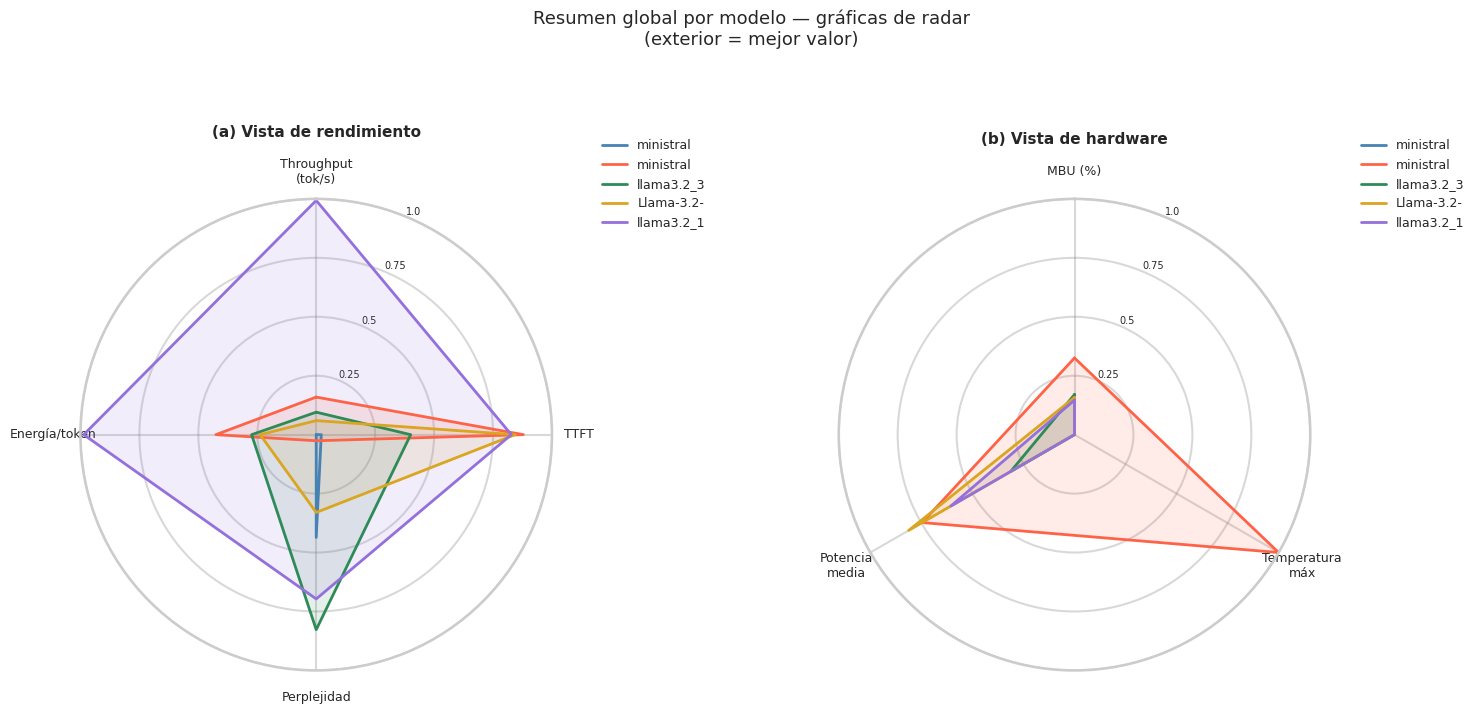

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def _radar_chart(
    df: pd.DataFrame,
    metrics: list[tuple[str, str, bool]],
    title: str,
    ax: plt.Axes,
    colors: list[str],
) -> None:
    """Draw a radar chart on ax.

    metrics: list of (column, label, higher_is_better)
    """
    # Keep only rows with all metrics available
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos suficientes",
                ha="center", va="center", transform=ax.transAxes)
        return

    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    # Normalize each metric to [0, 1] (1 = best)
    normalized = {}
    for col, _, higher_is_better in metrics:
        col_min = data[col].min()
        col_max = data[col].max()
        rng = col_max - col_min if col_max != col_min else 1.0
        if higher_is_better:
            normalized[col] = (data[col] - col_min) / rng
        else:
            normalized[col] = (col_max - data[col]) / rng

    # Draw grid and labels
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], size=7)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontsize=11, fontweight="bold")

    # Plot each model
    for (_, row), color in zip(data.iterrows(), colors):
        vals = [normalized[col][row.name] for col, _, _ in metrics]
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)

    ax.legend(loc="upper right",
              bbox_to_anchor=(1.35, 1.15), fontsize=9)


# Preparar el summary con model_label
summary_r = summary.copy()
if "model_label" not in summary_r.columns:
    summary_r["model_label"] = summary_r["model_short"].map(
        lambda x: x[:10]
    )

colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple"]

# Vista (a): rendimiento
perf_metrics = [
    ("tokens_per_s_mean",     "Throughput\n(tok/s)",    True),
    ("ttft_ms_mean",          "TTFT",                   False),  # menor = mejor
    ("perplexity_geomean",    "Perplejidad",            False),  # menor = mejor
    ("energy_per_token_j",    "Energía/token",          False),  # menor = mejor
]
perf_metrics_available = [
    (c, l, h) for c, l, h in perf_metrics
    if c in summary_r.columns
]

# Vista (b): hardware
hw_metrics_radar = [
    ("mbu_pct",        "MBU (%)",          True),
    ("temp_max_c",     "Temperatura\nmáx", False),  # menor = mejor
    ("power_mean_w",   "Potencia\nmedia",  False),  # menor = mejor
    ("mem_pct_mean",   "Memoria (%)",      False),  # menor = mejor (si existe)
]
hw_metrics_available = [
    (c, l, h) for c, l, h in hw_metrics_radar
    if c in summary_r.columns
]

fig = plt.figure(figsize=(16, 7))

if perf_metrics_available:
    ax_perf = fig.add_subplot(121, polar=True)
    _radar_chart(summary_r, perf_metrics_available,
                 "(a) Vista de rendimiento", ax_perf, colors_radar)

if hw_metrics_available:
    ax_hw = fig.add_subplot(122, polar=True)
    _radar_chart(summary_r, hw_metrics_available,
                 "(b) Vista de hardware", ax_hw, colors_radar)

if not perf_metrics_available and not hw_metrics_available:
    print("Sin métricas suficientes para el radar.")
else:
    fig.suptitle(
        "Resumen global por modelo — gráficas de radar\n"
        "(exterior = mejor valor)",
        y=1.03, fontsize=13,
    )
    plt.tight_layout()
    plt.show()
